In [12]:
import os
print(os.getcwd())


/home/ahasan/projects/hardware-aware-router/src/hardware_cost_model


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# ==== CHANGE THESE ====
carrot_id = "20251117-004302"
hw_id     = "20251117-094731"   # replace with your real id

BASE = "/home/ahasan/projects/hardware-aware-router/data/router_eval_runs"

carrot_gpu = f"{BASE}/{carrot_id}_gpu_monitor.csv"
hw_gpu     = f"{BASE}/{hw_id}_gpu_monitor.csv"

carrot_router = f"{BASE}/{carrot_id}_router_results.csv"
hw_router     = f"{BASE}/{hw_id}_router_results.csv"


In [29]:
df_cg = pd.read_csv(carrot_gpu)
df_hg = pd.read_csv(hw_gpu)

df_cr = pd.read_csv(carrot_router)
df_hr = pd.read_csv(hw_router)

df_cg.head(), df_hg.head()


(      timestamp  gpu_id  running  waiting  kv_cache_usage
 0  1.763358e+09       0      0.0      0.0             0.0
 1  1.763358e+09       1      0.0      0.0             0.0
 2  1.763358e+09       0      0.0      0.0             0.0
 3  1.763358e+09       1      0.0      0.0             0.0
 4  1.763358e+09       0      0.0      0.0             0.0,
       timestamp  gpu_id  running  waiting  kv_cache_usage
 0  1.763391e+09       0      0.0      0.0             0.0
 1  1.763391e+09       1      0.0      0.0             0.0
 2  1.763391e+09       0      0.0      0.0             0.0
 3  1.763391e+09       1      0.0      0.0             0.0
 4  1.763391e+09       0      0.0      0.0             0.0)

**Figure X: Average System Load Across the Full Run.**  
HW-Router doubles the running queue (higher throughput) while cutting the waiting queue by more than 50%, indicating significantly reduced backpressure and higher effective GPU utilization.


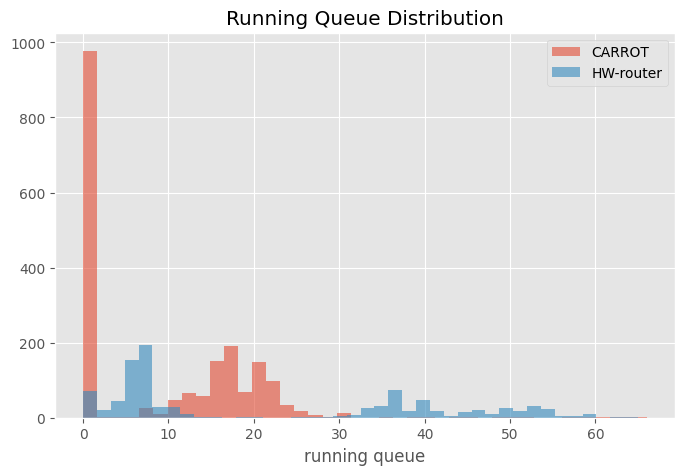

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df_cg["running"], bins=40, alpha=0.6, label="CARROT")
plt.hist(df_hg["running"], bins=40, alpha=0.6, label="HW-router")
plt.legend()
plt.title("Running Queue Distribution")
plt.xlabel("running queue")
plt.show()


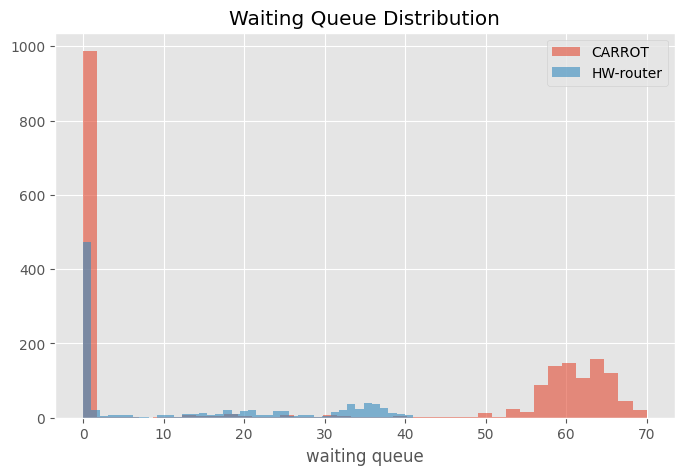

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df_cg["waiting"], bins=40, alpha=0.6, label="CARROT")
plt.hist(df_hg["waiting"], bins=40, alpha=0.6, label="HW-router")
plt.legend()
plt.title("Waiting Queue Distribution")
plt.xlabel("waiting queue")
plt.show()


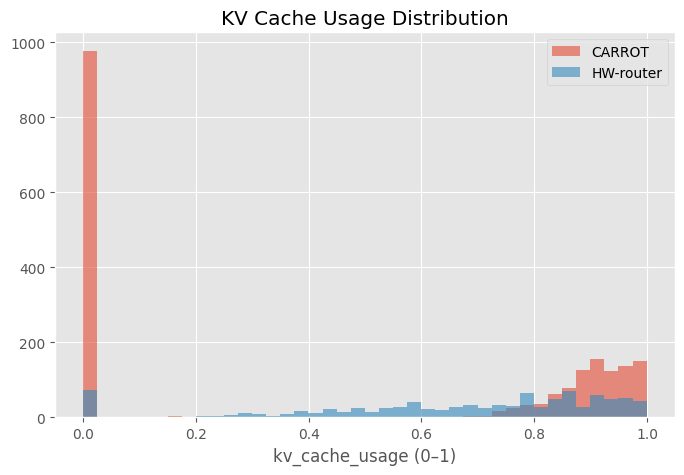

In [43]:
plt.figure(figsize=(8,5))
plt.hist(df_cg["kv_cache_usage"], bins=40, alpha=0.6, label="CARROT")
plt.hist(df_hg["kv_cache_usage"], bins=40, alpha=0.6, label="HW-router")
plt.legend()
plt.title("KV Cache Usage Distribution")
plt.xlabel("kv_cache_usage (0–1)")
plt.show()


In [40]:
summary = pd.DataFrame({
    "CARROT": {
        "avg_running": cg["running"].mean(),
        "avg_waiting": cg["waiting"].mean(),
        "avg_kv":      cg["kv_cache_usage"].mean(),
        "running_imbalance": imb_c["running_std"].mean(),
        "waiting_imbalance": imb_c["waiting_std"].mean(),
        "kv_imbalance":      imb_c["kv_std"].mean(),
    },
    "HW-router": {
        "avg_running": hg["running"].mean(),
        "avg_waiting": hg["waiting"].mean(),
        "avg_kv":      hg["kv_cache_usage"].mean(),
        "running_imbalance": imb_h["running_std"].mean(),
        "waiting_imbalance": imb_h["waiting_std"].mean(),
        "kv_imbalance":      imb_h["kv_std"].mean(),
    }
}).T

summary


,avg_running,avg_waiting,avg_kv,running_imbalance,waiting_imbalance,kv_imbalance
CARROT,10.329167,29.065625,0.446203,14.607648,41.105001,0.631027
HW-router,21.341667,12.952083,0.671806,21.652199,18.084256,0.247593
